In [1]:
import pandas as pd

# exibir todas as colunas
pd.set_option('display.max_columns', None)

url = "https://raw.githubusercontent.com/tmedeirosb/tsi-ad-2025/refs/heads/main/dados/dados_workflow_ivan.csv"
df = pd.read_csv(url)

display(df.head())

,LnguaPortuguesaeLiteraturaI90H,LnguaPortuguesaeLiteraturaI90H_dependencia,LnguaPortuguesaeLiteraturaI90H_freq,MatemticaI120H,MatemticaI120H_dependencia,MatemticaI120H_freq,aluno_exclusivo_rede_publica,descricao,descricao_area_residencial,descricao_companhia_domiciliar,descricao_estado_civil,descricao_historico,descricao_imovel,descricao_mae_escolaridade,descricao_pai_escolaridade,descricao_raca,descricao_responsavel_escolaridade,descricao_responsavel_financeiro,descricao_trabalho,id,idade,pessoa_fisica__sexo,possui_necessidade_especial,qnt_pc,qtd_pessoas_domicilio,sigla,tempo_entre_conclusao_ingresso,qnt_salarios,artificial,classe,conceito,conceito_freq,acompanhamento
0,68.0,0,100.0,66.0,0,100.0,False,Matriculado,Urbana,Mãe,Solteiro(a),Técnico de Nivel Médio em Informática,Alugado,Ensino fundamental incompleto,Ensino fundamental incompleto,Branca,Ensino fundamental incompleto,Mãe,Não informado,457884597605,15,F,False,0,2,LAJ,1,1,0,1,B,A,0
1,73.0,1,100.0,36.0,1,91.0,False,Cancelado,Urbana,Mãe,Solteiro(a),Técnico de Nível Médio em Meio Ambiente,Alugado,Ensino fundamental incompleto,Ensino fundamental incompleto,Parda,Ensino fundamental incompleto,Mãe,Não informado,458436647741,17,M,False,1,2,SPP,2,1,1,0,R,R,0
2,61.0,0,100.0,60.0,0,100.0,False,Matriculado,Urbana,Pais,Solteiro(a),Técnico de Nivel Médio em Informática,Alugado,Ensino médio completo,Ensino médio completo,Parda,Ensino médio completo,Mãe,Não informado,464029640533,15,M,True,0,5,CANG,2,2,0,1,B,A,0
3,NaN,-1,NaN,NaN,-1,NaN,False,Matriculado,Urbana,Pais,Solteiro(a),Técnico de Nível Médio em Mecânica,Alugado,Alfabetizado,Não estudou,Parda,Ensino fundamental incompleto,Mãe,Não está trabalhando,556372572373,16,F,False,1,5,MO,3,2,0,1,S,S,0
4,69.0,0,100.0,63.0,0,100.0,False,Matriculado,Urbana,Mãe,Solteiro(a),Técnico de Nivel Médio Informática,Alugado,Ensino fundamental incompleto,Ensino fundamental incompleto,Preta,Ensino fundamental incompleto,Mãe,Não está trabalhando,457614148801,15,F,False,0,3,PAR,1,1,0,1,R,A,2


In [2]:
df_sel = df[['LnguaPortuguesaeLiteraturaI90H', 'MatemticaI120H', 'descricao_responsavel_escolaridade', 'idade', 'descricao_raca', 'pessoa_fisica__sexo', 'classe']]
df_sel

,LnguaPortuguesaeLiteraturaI90H,MatemticaI120H,descricao_responsavel_escolaridade,idade,descricao_raca,pessoa_fisica__sexo,classe
0,68.0,66.0,Ensino fundamental incompleto,15,Branca,F,1
1,73.0,36.0,Ensino fundamental incompleto,17,Parda,M,0
2,61.0,60.0,Ensino médio completo,15,Parda,M,1
3,NaN,NaN,Ensino fundamental incompleto,16,Parda,F,1
4,69.0,63.0,Ensino fundamental incompleto,15,Preta,F,1
...,...,...,...,...,...,...,...
8903,29.0,11.0,Ensino fundamental incompleto,15,Amarela,M,0
8904,86.0,71.0,Ensino fundamental incompleto,15,Branca,F,1
8905,61.0,67.0,Ensino fundamental incompleto,15,Parda,F,1
8906,93.0,78.0,Ensino fundamental incompleto,14,Parda,F,1


In [3]:
# Inverter os valores da classe (0 -> 1, 1 -> 0) - igual ao MODULO_08
df_sel['classe'] = 1 - df_sel['classe']

print("Classe invertida!")
print(f"Distribuição da classe (invertida):\n{df_sel['classe'].value_counts()}")

Classe invertida!
Distribuição da classe (invertida):
classe
0    8352
1     556
Name: count, dtype: int64


/var/folders/qq/pvvjcqys15v14km9lr6xcy1w0000gn/T/ipykernel_31024/3781192298.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sel['classe'] = 1 - df_sel['classe']


In [4]:
#%pip install 'pycaret[full]' -q

## PyCaret AutoML - Setup e Configuração

O PyCaret automatiza todo o pipeline de Machine Learning: pré-processamento, seleção de features, comparação de modelos, tuning de hiperparâmetros e interpretabilidade.

In [5]:
from pycaret.classification import *

# Configurar o ambiente PyCaret
# O setup automaticamente:
# - Identifica tipos de dados (numéricos e categóricos)
# - Aplica pré-processamento (imputação, encoding, normalização)
# - Divide os dados em treino e teste

clf_setup = setup(
    data=df_sel,
    target='classe',
    train_size=0.8,
    session_id=42,
    normalize=True,
    normalize_method='minmax',
    categorical_features=['descricao_responsavel_escolaridade', 'descricao_raca', 'pessoa_fisica__sexo'],
    numeric_features=['LnguaPortuguesaeLiteraturaI90H', 'MatemticaI120H', 'idade'],
    imputation_type='simple',
    numeric_imputation='median',
    categorical_imputation='mode',
    fix_imbalance=False,
    verbose=True
)

,Description,Value
0,Session id,42
1,Target,classe
2,Target type,Binary
3,Original data shape,"(8908, 7)"
4,Transformed data shape,"(8908, 22)"
5,Transformed train set shape,"(7126, 22)"
6,Transformed test set shape,"(1782, 22)"
7,Numeric features,3
8,Categorical features,3
9,Rows with missing values,19.1%


## Comparação Automática de Modelos

O PyCaret treina e compara automaticamente diversos algoritmos de classificação.

In [6]:
# Comparar todos os modelos disponíveis
# Ordenar por AUC (ou outra métrica de interesse)
best_models = compare_models(
    sort='AUC',
    n_select=3,  # Selecionar os 3 melhores modelos
    fold=5,      # 5-fold cross-validation
    verbose=True
)

# Exibir o melhor modelo
print(f"\nMelhor modelo selecionado: {best_models[0]}")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.9427,0.8815,0.3461,0.5704,0.4301,0.4019,0.4162,0.0580
catboost,CatBoost Classifier,0.9453,0.8758,0.3461,0.6103,0.4408,0.4144,0.4333,0.3660
lda,Linear Discriminant Analysis,0.9441,0.8750,0.5213,0.5567,0.5377,0.5080,0.5087,0.0100
ridge,Ridge Classifier,0.9399,0.8742,0.1663,0.5586,0.2532,0.2321,0.2802,0.0120
ada,Ada Boost Classifier,0.9413,0.8739,0.3416,0.5504,0.4205,0.3914,0.4043,0.2420
lr,Logistic Regression,0.9432,0.8724,0.3056,0.5874,0.3994,0.3729,0.3961,0.4420
lightgbm,Light Gradient Boosting Machine,0.9441,0.8623,0.3798,0.5849,0.4594,0.4313,0.4431,0.4640
rf,Random Forest Classifier,0.9446,0.8544,0.3371,0.6027,0.4319,0.4052,0.4244,0.2540
svm,SVM - Linear Kernel,0.9413,0.8512,0.3101,0.5512,0.3839,0.3574,0.3782,0.0100
xgboost,Extreme Gradient Boosting,0.9422,0.8510,0.3596,0.5605,0.4370,0.4081,0.4198,0.0180



Melhor modelo selecionado: GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=42, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)


In [7]:
# Capturar a tabela de comparação dos modelos (deve ser feito logo após compare_models)
from pycaret.classification import pull

comparison_df = pull()
print("Tabela de Comparação dos Top 3 Modelos:")
display(comparison_df)

Tabela de Comparação dos Top 3 Modelos:


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.9427,0.8815,0.3461,0.5704,0.4301,0.4019,0.4162,0.058
catboost,CatBoost Classifier,0.9453,0.8758,0.3461,0.6103,0.4408,0.4144,0.4333,0.366
lda,Linear Discriminant Analysis,0.9441,0.8750,0.5213,0.5567,0.5377,0.5080,0.5087,0.010
ridge,Ridge Classifier,0.9399,0.8742,0.1663,0.5586,0.2532,0.2321,0.2802,0.012
ada,Ada Boost Classifier,0.9413,0.8739,0.3416,0.5504,0.4205,0.3914,0.4043,0.242
lr,Logistic Regression,0.9432,0.8724,0.3056,0.5874,0.3994,0.3729,0.3961,0.442
lightgbm,Light Gradient Boosting Machine,0.9441,0.8623,0.3798,0.5849,0.4594,0.4313,0.4431,0.464
rf,Random Forest Classifier,0.9446,0.8544,0.3371,0.6027,0.4319,0.4052,0.4244,0.254
svm,SVM - Linear Kernel,0.9413,0.8512,0.3101,0.5512,0.3839,0.3574,0.3782,0.010
xgboost,Extreme Gradient Boosting,0.9422,0.8510,0.3596,0.5605,0.4370,0.4081,0.4198,0.018


## Fine-Tuning do Melhor Modelo

Otimização de hiperparâmetros do melhor modelo selecionado automaticamente.

In [8]:
# Fine-tuning do melhor modelo (best_models[0])
best_model = best_models[0]
print(f"Melhor modelo antes do tuning: {best_model}")

# Otimizar hiperparâmetros usando Random Search
best_model_tuned = tune_model(
    best_model,
    optimize='AUC',
    search_library='scikit-learn',
    search_algorithm='random',
    n_iter=30,
    fold=5,
    verbose=True
)

print(f"\nMelhor modelo após tuning: {best_model_tuned}")
print(f"\nHiperparâmetros otimizados:")
for param, value in best_model_tuned.get_params().items():
    print(f"  {param}: {value}")

Melhor modelo antes do tuning: GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=42, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9453,0.8786,0.4270,0.5846,0.4935,0.4653,0.4718
1,0.9418,0.8696,0.3483,0.5536,0.4276,0.3986,0.4105
2,0.9460,0.8817,0.4045,0.6000,0.4832,0.4559,0.4657
3,0.9481,0.9183,0.3933,0.6364,0.4861,0.4604,0.4752
4,0.9432,0.8782,0.4045,0.5625,0.4706,0.4414,0.4481
Mean,0.9448,0.8853,0.3955,0.5874,0.4722,0.4443,0.4543
Std,0.0022,0.0170,0.0260,0.0294,0.0235,0.0242,0.0238


Fitting 5 folds for each of 30 candidates, totalling 150 fits

Melhor modelo após tuning: GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.05, loss='log_loss', max_depth=6,
                           max_features='sqrt', max_leaf_nodes=None,
                           min_impurity_decrease=0.3, min_samples_leaf=4,
                           min_samples_split=10, min_weight_fraction_leaf=0.0,
                           n_estimators=270, n_iter_no_change=None,
                           random_state=42, subsample=0.7, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)

Hiperparâmetros otimizados:
  ccp_alpha: 0.0
  criterion: friedman_mse
  init: None
  learning_rate: 0.05
  loss: log_loss
  max_depth: 6
  max_features: sqrt
  max_leaf_nodes: None
  min_impurity_decrease: 0.3
  min_samples_leaf: 4
  min_samples_split: 10
  min_weight_fraction_leaf:

## Avaliação do Melhor Modelo no Holdout

Avaliar o desempenho do modelo tunado no conjunto de teste.

In [9]:
# Avaliar o melhor modelo tunado no conjunto de teste (holdout)
print("="*70)
print(f"AVALIAÇÃO DO MELHOR MODELO TUNADO NO HOLDOUT")
print("="*70)

# Fazer predições no holdout
predicoes_best = predict_model(best_model_tuned)
display(predicoes_best.head(10))

AVALIAÇÃO DO MELHOR MODELO TUNADO NO HOLDOUT


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.9506,0.8905,0.4775,0.6386,0.5464,0.5209,0.5270


,LnguaPortuguesaeLiteraturaI90H,MatemticaI120H,descricao_responsavel_escolaridade,idade,descricao_raca,pessoa_fisica__sexo,classe,prediction_label,prediction_score
1948,60.0,73.0,Ensino superior completo,17,Amarela,F,0,0,0.9626
7460,94.0,100.0,Ensino superior incompleto,14,Branca,F,0,0,0.9845
8378,94.0,70.0,Ensino médio incompleto,15,Branca,M,0,0,0.9845
4228,NaN,NaN,Ensino superior completo,14,Amarela,F,0,0,0.9845
8513,42.0,20.0,Ensino médio incompleto,14,Parda,M,0,0,0.6861
1778,60.0,33.0,Ensino fundamental incompleto,15,Parda,M,0,0,0.9092
3416,62.0,62.0,Ensino fundamental incompleto,15,Parda,F,0,0,0.9827
6069,93.0,88.0,Ensino superior incompleto,15,Parda,F,0,0,0.9845
710,74.0,87.0,Ensino médio completo,15,Branca,M,0,0,0.9848
6376,48.0,18.0,Ensino médio incompleto,16,Parda,F,1,0,0.7146


## Visualização - Matriz de Confusão e Curva ROC

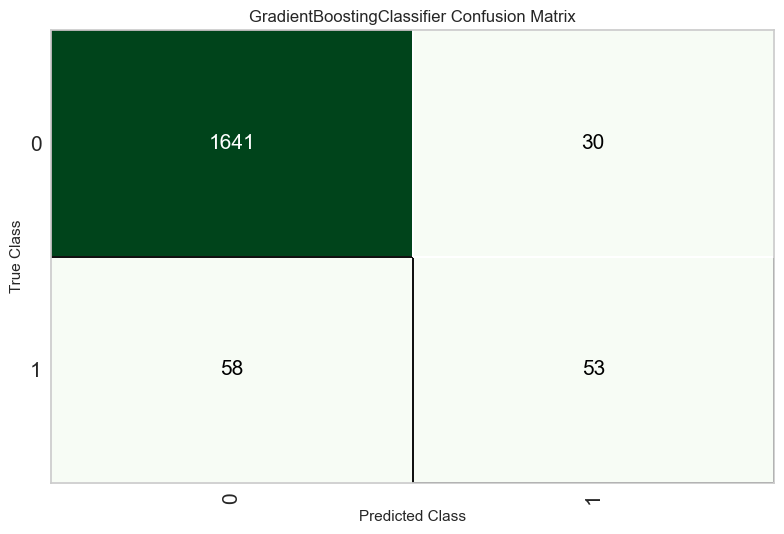

In [10]:
# Matriz de Confusão do melhor modelo
plot_model(best_model_tuned, plot='confusion_matrix')

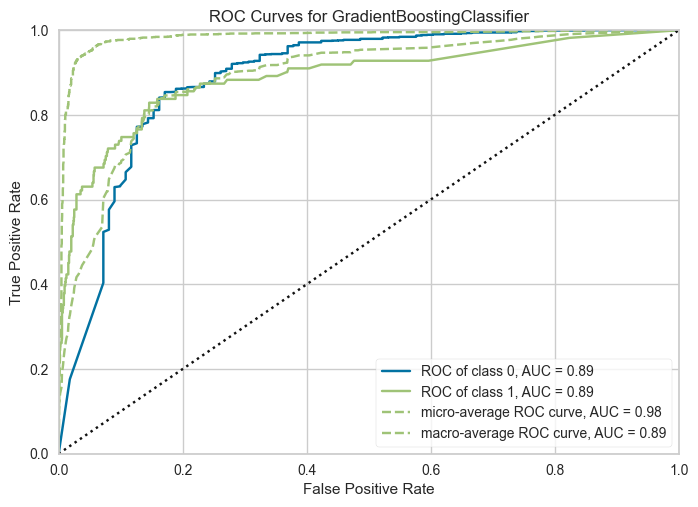

In [11]:
# Curva ROC do melhor modelo
plot_model(best_model_tuned, plot='auc')

## Comparação de Modelos com Gráfico de Barras

Tabela de Comparação dos Modelos:


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.9427,0.8815,0.3461,0.5704,0.4301,0.4019,0.4162,0.058
catboost,CatBoost Classifier,0.9453,0.8758,0.3461,0.6103,0.4408,0.4144,0.4333,0.366
lda,Linear Discriminant Analysis,0.9441,0.8750,0.5213,0.5567,0.5377,0.5080,0.5087,0.010
ridge,Ridge Classifier,0.9399,0.8742,0.1663,0.5586,0.2532,0.2321,0.2802,0.012
ada,Ada Boost Classifier,0.9413,0.8739,0.3416,0.5504,0.4205,0.3914,0.4043,0.242
lr,Logistic Regression,0.9432,0.8724,0.3056,0.5874,0.3994,0.3729,0.3961,0.442
lightgbm,Light Gradient Boosting Machine,0.9441,0.8623,0.3798,0.5849,0.4594,0.4313,0.4431,0.464
rf,Random Forest Classifier,0.9446,0.8544,0.3371,0.6027,0.4319,0.4052,0.4244,0.254
svm,SVM - Linear Kernel,0.9413,0.8512,0.3101,0.5512,0.3839,0.3574,0.3782,0.010
xgboost,Extreme Gradient Boosting,0.9422,0.8510,0.3596,0.5605,0.4370,0.4081,0.4198,0.018


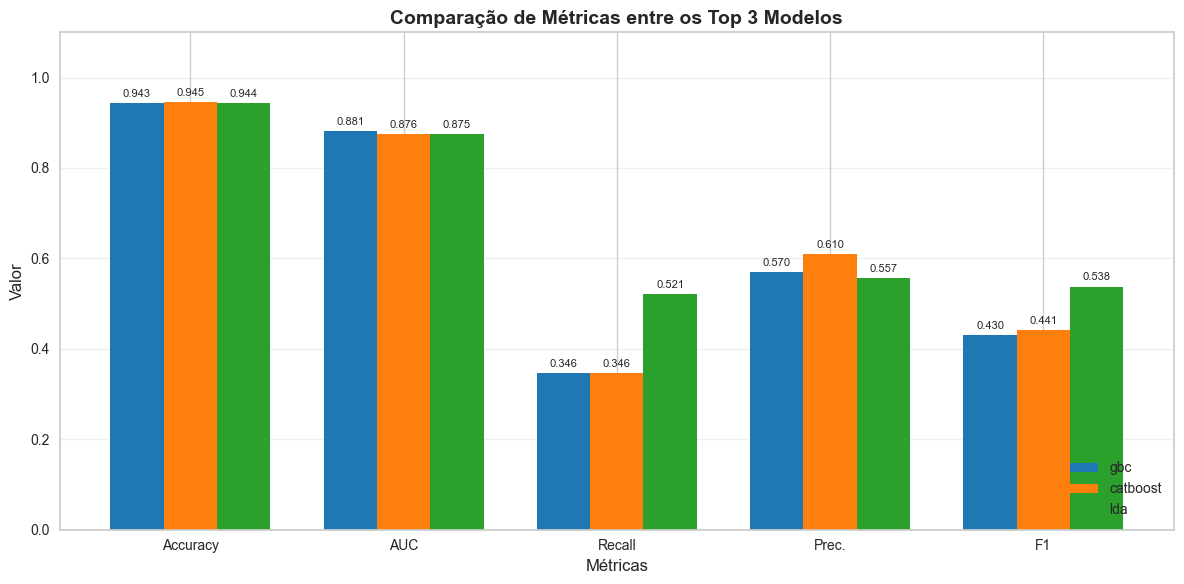

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Usar a comparison_df já capturada da célula anterior
print("Tabela de Comparação dos Modelos:")
display(comparison_df)

# Selecionar as métricas para comparação
metricas = ['Accuracy', 'AUC', 'Recall', 'Prec.', 'F1']
modelos_nomes = comparison_df.index[:3].tolist()  # Top 3 modelos

# Criar gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metricas))
width = 0.25
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, modelo in enumerate(modelos_nomes):
    valores = [comparison_df.loc[modelo, m] for m in metricas]
    bars = ax.bar(x + i*width, valores, width, label=modelo, color=colors[i])
    # Adicionar valores nas barras
    for bar, val in zip(bars, valores):
        ax.annotate(f'{val:.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Métricas', fontsize=12)
ax.set_ylabel('Valor', fontsize=12)
ax.set_title('Comparação de Métricas entre os Top 3 Modelos', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metricas)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Interpretabilidade do Melhor Modelo (SHAP e Feature Importance)

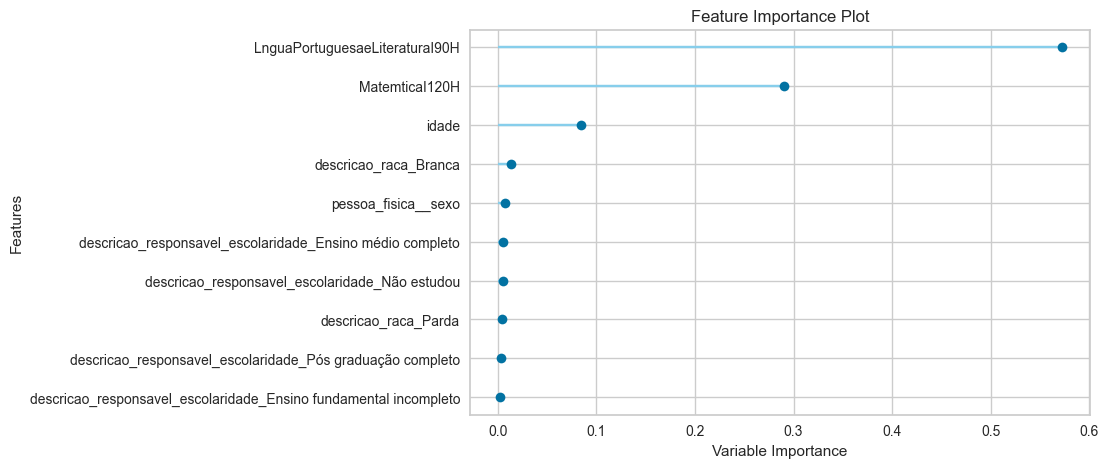

In [13]:
# Feature Importance do melhor modelo
# Verificar se o modelo suporta feature importance
try:
    plot_model(best_model_tuned, plot='feature')
except Exception as e:
    print(f"Feature Importance não disponível para este tipo de modelo: {e}")

## Salvar e Carregar o Melhor Modelo

In [14]:
# Finalizar o melhor modelo (retreina com todos os dados)
modelo_final = finalize_model(best_model_tuned)
print("Modelo finalizado (retreinado com todos os dados):")
print(modelo_final)

Modelo finalizado (retreinado com todos os dados):
Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['LnguaPortuguesaeLiteraturaI90H',
                                             'MatemticaI120H', 'idade'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empty_features=False,
                                                              missing_values=nan,
                                                              strategy='median'))),
                ('categorical_imputer',
                 TransformerWrapper(excl...
                                            criterion='friedman_mse', init=None,
               

In [15]:
# Salvar o modelo usando PyCaret
save_model(modelo_final, 'melhor_modelo_pycaret')
print("Modelo salvo com sucesso como 'melhor_modelo_pycaret.pkl'")

Transformation Pipeline and Model Successfully Saved
Modelo salvo com sucesso como 'melhor_modelo_pycaret.pkl'


In [16]:
# Carregar o modelo salvo
modelo_carregado = load_model('melhor_modelo_pycaret')
print("Modelo carregado com sucesso!")
print(type(modelo_carregado))

Transformation Pipeline and Model Successfully Loaded
Modelo carregado com sucesso!
<class 'pycaret.internal.pipeline.Pipeline'>


## Predição com Dados Fictícios usando o Modelo Carregado

In [17]:
# Criar dados fictícios para teste de predição
# Usar as mesmas colunas e categorias do dataset original

# Extrair categorias únicas das variáveis categóricas
escolaridade_cats = df_sel['descricao_responsavel_escolaridade'].unique().tolist()
raca_cats = df_sel['descricao_raca'].unique().tolist()
sexo_cats = df_sel['pessoa_fisica__sexo'].unique().tolist()

print("Categorias disponíveis:")
print(f"Escolaridade: {escolaridade_cats}")
print(f"Raça: {raca_cats}")
print(f"Sexo: {sexo_cats}")

# Criar DataFrame com dados fictícios
dados_ficticios = pd.DataFrame({
    'LnguaPortuguesaeLiteraturaI90H': [7.5, 4.2, 9.0, 5.5, 8.0],
    'MatemticaI120H': [6.8, 3.5, 8.5, 6.0, 7.2],
    'descricao_responsavel_escolaridade': [escolaridade_cats[0], escolaridade_cats[1] if len(escolaridade_cats) > 1 else escolaridade_cats[0], 
                                            escolaridade_cats[0], escolaridade_cats[2] if len(escolaridade_cats) > 2 else escolaridade_cats[0],
                                            escolaridade_cats[0]],
    'idade': [18, 22, 19, 25, 20],
    'descricao_raca': [raca_cats[0], raca_cats[1] if len(raca_cats) > 1 else raca_cats[0], 
                       raca_cats[0], raca_cats[2] if len(raca_cats) > 2 else raca_cats[0],
                       raca_cats[0]],
    'pessoa_fisica__sexo': [sexo_cats[0], sexo_cats[1] if len(sexo_cats) > 1 else sexo_cats[0], 
                            sexo_cats[0], sexo_cats[1] if len(sexo_cats) > 1 else sexo_cats[0],
                            sexo_cats[0]]
})

print("\nDados fictícios para predição:")
display(dados_ficticios)

Categorias disponíveis:
Escolaridade: ['Ensino fundamental incompleto', 'Ensino médio completo', 'Alfabetizado', 'Pós graduação completo', 'Ensino superior completo', 'Ensino médio incompleto', 'Ensino fundamental completo', 'Não estudou', 'Ensino superior incompleto', 'Pós graduação incompleto', 'Não conhece']
Raça: ['Branca', 'Parda', 'Preta', 'Amarela', 'Não declarado', 'Indígena']
Sexo: ['F', 'M']

Dados fictícios para predição:


,LnguaPortuguesaeLiteraturaI90H,MatemticaI120H,descricao_responsavel_escolaridade,idade,descricao_raca,pessoa_fisica__sexo
0,7.5,6.8,Ensino fundamental incompleto,18,Branca,F
1,4.2,3.5,Ensino médio completo,22,Parda,M
2,9.0,8.5,Ensino fundamental incompleto,19,Branca,F
3,5.5,6.0,Alfabetizado,25,Preta,M
4,8.0,7.2,Ensino fundamental incompleto,20,Branca,F


In [18]:
# Fazer predições com o modelo carregado
predicoes_ficticias = predict_model(modelo_carregado, data=dados_ficticios)

print("="*70)
print("PREDIÇÕES COM DADOS FICTÍCIOS")
print("="*70)
display(predicoes_ficticias)

# Interpretação dos resultados
print("\nInterpretação das predições:")
print("-" * 50)
for i, row in predicoes_ficticias.iterrows():
    classe_pred = row['prediction_label']
    score = row['prediction_score']
    status = "EVASÃO" if classe_pred == 1 else "PERMANÊNCIA"
    print(f"Aluno {i+1}: {status} (confiança: {score:.2%})")

PREDIÇÕES COM DADOS FICTÍCIOS


,LnguaPortuguesaeLiteraturaI90H,MatemticaI120H,descricao_responsavel_escolaridade,idade,descricao_raca,pessoa_fisica__sexo,prediction_label,prediction_score
0,7.5,6.8,Ensino fundamental incompleto,18,Branca,F,1,0.7895
1,4.2,3.5,Ensino médio completo,22,Parda,M,1,0.7178
2,9.0,8.5,Ensino fundamental incompleto,19,Branca,F,1,0.8733
3,5.5,6.0,Alfabetizado,25,Preta,M,1,0.9243
4,8.0,7.2,Ensino fundamental incompleto,20,Branca,F,1,0.8681



Interpretação das predições:
--------------------------------------------------
Aluno 1: EVASÃO (confiança: 78.95%)
Aluno 2: EVASÃO (confiança: 71.78%)
Aluno 3: EVASÃO (confiança: 87.33%)
Aluno 4: EVASÃO (confiança: 92.43%)
Aluno 5: EVASÃO (confiança: 86.81%)


## Conclusão

Este notebook demonstrou o pipeline completo de Machine Learning usando **PyCaret AutoML**:

1. **Carregamento e Preparação dos Dados**: Inversão das classes (0↔1)
2. **Setup do PyCaret**: Configuração com normalização MinMax e imputação automática
3. **Comparação de Modelos**: `compare_models()` para encontrar os top 3 modelos automaticamente
4. **Fine-Tuning**: Otimização de hiperparâmetros com `tune_model()` no melhor modelo
5. **Avaliação**: Predições no holdout com métricas e visualizações
6. **Comparação Visual**: Gráfico de barras comparando as métricas dos top 3 modelos
7. **Interpretabilidade**: Feature Importance e SHAP plots
8. **Persistência**: Salvar e carregar o modelo com `save_model()` e `load_model()`
9. **Predição**: Teste com dados fictícios usando o modelo carregado

O **PyCaret** simplifica significativamente o processo de desenvolvimento de modelos de ML, automatizando muitas etapas que normalmente requerem código extenso com sklearn.